# **Analisis Statistik Nilai Impor Menurut Golongan Barang Ekonomi: Tinjauan Dinamika Pasca-Pandemi (Data Tahun 2024-2025)**

        HASIL ANALISIS STATISTIK DESKRIPTIF 2024

>>> GOLONGAN: BARANG KONSUMSI
    Rata-rata (Mean) :    1894.22 Juta US$
    Nilai Tengah     :    1859.10 Juta US$
    Standar Deviasi  :     216.50
    Nilai Minimum    :    1439.20
    Nilai Maksimum   :    2307.30

>>> GOLONGAN: BAHAN BAKU INDUSTRI
    Rata-rata (Mean) :    6384.48 Juta US$
    Nilai Tengah     :    6539.00 Juta US$
    Standar Deviasi  :     728.68
    Nilai Minimum    :    5126.90
    Nilai Maksimum   :    7277.20



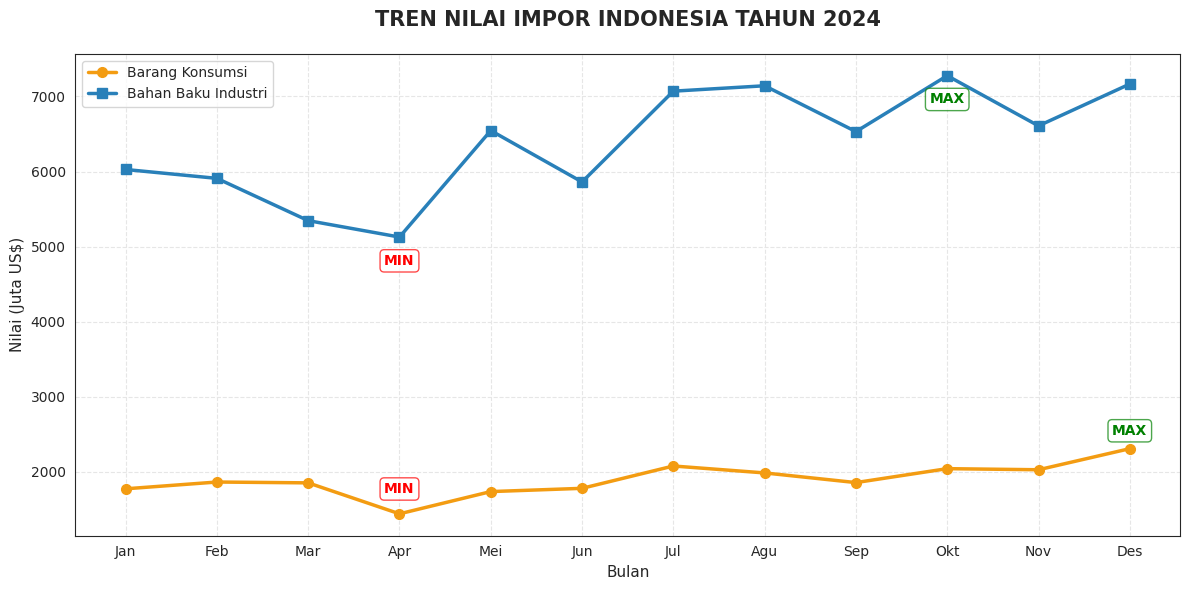

/tmp/ipykernel_6234/1562209595.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Golongan', y='Nilai', data=df_melted, palette=palette, width=0.4)
/tmp/ipykernel_6234/1562209595.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Barang Konsumsi', 'Bahan Baku Industri'], fontsize=12)


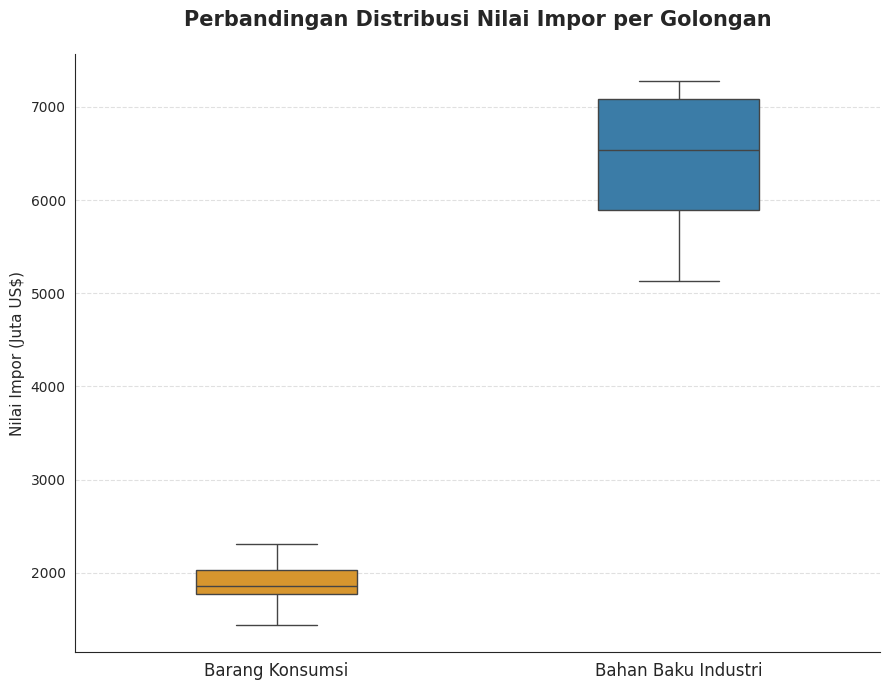

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =================================================================
# ANALISIS STATISTIK IMPOR INDONESIA 2024
# =================================================================

def load_data():
    """Menyiapkan dataset impor berdasarkan data BPS 2024"""
    data = {
        'Bulan': ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'],
        'Barang_Konsumsi': [1772.4, 1862.8, 1851.6, 1439.2, 1735.4, 1778.8, 2076.4, 1984.1, 1855.4, 2040.9, 2026.3, 2307.3],
        'Bahan_Baku_Industri': [6027.2, 5909.0, 5345.7, 5126.9, 6546.0, 5861.1, 7071.0, 7142.8, 6532.0, 7277.2, 6608.7, 7166.2]
    }
    return pd.DataFrame(data)

def display_statistics(df):
    """Menghitung dan menampilkan statistik deskriptif di konsol"""
    print("="*55)
    print("        HASIL ANALISIS STATISTIK DESKRIPTIF 2024")
    print("="*55)

    categories = {
        'Barang Konsumsi': 'Barang_Konsumsi',
        'Bahan Baku Industri': 'Bahan_Baku_Industri'
    }

    for label, col in categories.items():
        stats = df[col].describe()
        print(f"\n>>> GOLONGAN: {label.upper()}")
        print(f"    Rata-rata (Mean) : {stats['mean']:>10.2f} Juta US$")
        print(f"    Nilai Tengah     : {stats['50%']:>10.2f} Juta US$")
        print(f"    Standar Deviasi  : {stats['std']:>10.2f}")
        print(f"    Nilai Minimum    : {stats['min']:>10.2f}")
        print(f"    Nilai Maksimum   : {stats['max']:>10.2f}")
    print("\n" + "="*55)

def plot_trends(df):
    """Membuat visualisasi tren bulanan (Gambar 3.1)"""
    plt.figure(figsize=(12, 6))
    # Background Putih
    sns.set_style("white", {'axes.grid': True, 'grid.color': '.9', 'grid.linestyle': '--'})

    # Plot Garis
    plt.plot(df['Bulan'], df['Barang_Konsumsi'], marker='o', markersize=7,
             label='Barang Konsumsi', color='#f39c12', linewidth=2.5)
    plt.plot(df['Bulan'], df['Bahan_Baku_Industri'], marker='s', markersize=7,
             label='Bahan Baku Industri', color='#2980b9', linewidth=2.5)

    # --- Penanda MIN & MAX Otomatis ---
    # Bahan Baku Industri
    max_idx_b = df['Bahan_Baku_Industri'].idxmax()
    min_idx_b = df['Bahan_Baku_Industri'].idxmin()
    plt.annotate('MAX', xy=(df['Bulan'][max_idx_b], df['Bahan_Baku_Industri'][max_idx_b]),
                 xytext=(0, -20), textcoords='offset points', ha='center',
                 color='green', fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='green', alpha=0.7))
    plt.annotate('MIN', xy=(df['Bulan'][min_idx_b], df['Bahan_Baku_Industri'][min_idx_b]),
                 xytext=(0, -20), textcoords='offset points', ha='center',
                 color='red', fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='red', alpha=0.7))

    # Barang Konsumsi
    max_idx_k = df['Barang_Konsumsi'].idxmax()
    min_idx_k = df['Barang_Konsumsi'].idxmin()
    plt.annotate('MAX', xy=(df['Bulan'][max_idx_k], df['Barang_Konsumsi'][max_idx_k]),
                 xytext=(0, 10), textcoords='offset points', ha='center',
                 color='green', fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='green', alpha=0.7))
    plt.annotate('MIN', xy=(df['Bulan'][min_idx_k], df['Barang_Konsumsi'][min_idx_k]),
                 xytext=(0, 15), textcoords='offset points', ha='center',
                 color='red', fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='red', alpha=0.7))

    # Styling
    plt.title('TREN NILAI IMPOR INDONESIA TAHUN 2024', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Bulan', fontsize=11)
    plt.ylabel('Nilai (Juta US$)', fontsize=11)
    plt.legend(loc='upper left', frameon=True)

    plt.tight_layout()
    plt.show()

def plot_distribution(df):
    """Membuat visualisasi distribusi menggunakan Boxplot (Gambar 3.2)"""
    plt.figure(figsize=(9, 7))
    sns.set_style("white")

    # Reshape data
    df_melted = df.melt(id_vars='Bulan', value_vars=['Barang_Konsumsi', 'Bahan_Baku_Industri'],
                        var_name='Golongan', value_name='Nilai')

    # Membuat Boxplot simple (Tanpa penanda min/max di sini sesuai permintaan sebelumnya)
    palette = {'Barang_Konsumsi': '#f39c12', 'Bahan_Baku_Industri': '#2980b9'}
    ax = sns.boxplot(x='Golongan', y='Nilai', data=df_melted, palette=palette, width=0.4)

    # Tambahkan garis grid halus hanya di sumbu Y
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    sns.despine()

    # Styling
    plt.title('Perbandingan Distribusi Nilai Impor per Golongan', fontsize=15, fontweight='bold', pad=20)
    plt.ylabel('Nilai Impor (Juta US$)', fontsize=11)
    plt.xlabel('')
    ax.set_xticklabels(['Barang Konsumsi', 'Bahan Baku Industri'], fontsize=12)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    try:
        df_impor = load_data()
        display_statistics(df_impor)
        plot_trends(df_impor)
        plot_distribution(df_impor)
    except Exception as e:
        print(f"\n[ERROR]: {e}")